# MDR-TS v10.1
**Temporal-Station Baseline for Soil Moisture Prediction (Reset Notebook)**

**Author:** Jakob Balkovec  
**Affiliation:** Seattle University, Computer Science  
**Project:** MDR  
**Notebook Type:** One long training + evaluation notebook  
**Last Updated:** Tue Feb 10, 2026

---

## Why this restart exists

Rain and seasonality are hard to model, and I’m starting over with a **new split** so the pipeline is clean and consistent. I’m keeping this notebook simple and focused: build one strong baseline first, then add uncertainty (bootstrapping), then test smarter modeling ideas (like two-model approaches). Also, I was losing my mind, so this is the reset.

---

## Model Summary

- **Task:** Regression (soil moisture at 5 cm depth)  
- **Target:** `soil_moisture_5cm`  
- **Temporal resolution:** Daily  
- **Baseline model:** XGBoost (single model first)

---

## Reproducibility

- **Random seed:** 42  
- **Split:** `/Users/jbalkovec/Desktop/MDR/Temporal/Pipeline/data/splits/derived_5.0`  
- **Environment:** local (MacBook M2 Pro)

---

## Notebook Plan (high level)

### 1) Train a strong baseline (XGBoost)
- Train a single XGB regressor on the new split
- Use `optuna` to find good hyperparameters
- Lock the best params and retrain cleanly

### 2) Bootstrap for stability
- Use bootstrapping to estimate performance variability
- Report mean + spread (e.g., mean \(R^2\) with confidence intervals)
- Identify failure modes (especially around wet periods / transitions)

### 3) Explore “hard problems” next (rain + seasonality)
Once the baseline is solid, try extensions:
- **Two-model approach** (example ideas)
  - wet vs dry split using a simple rain gate
  - winter vs non-winter split using DOY bins or a smooth seasonal score
- Compare against the baseline with the same evaluation setup

---

## Evaluation (keep it basic at first)

Report:
- Overall test \(R^2\) and MAE
- Optional breakdowns (diagnostic only):
  - wet vs dry (using a simple rain threshold)
  - winter vs non-winter (DOY bins)

Success means:
- baseline is strong and repeatable
- improvements don’t just shift error around
- wet/winter performance stops collapsing as badly

---

## Notes / reminders

- No leakage: anything threshold-based must be computed from train only.
- Start simple: one good model before clever routing.
- Don’t over-engineer the first pass.

## 0. Imports

In [1]:
import os
import json
import math
import random
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from xgboost import XGBRegressor
import optuna
from optuna.integration import XGBoostPruningCallback
from optuna.visualization import plot_optimization_history, plot_param_importances

import warnings
warnings.filterwarnings("ignore")

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

print("imports loaded")
print(f"seed: {SEED}")

imports loaded
seed: 42


## 1. Data Access

In [2]:
# Project paths
VERSION = "v10"
SUBVERSION = "v10.1"
RUN_NAME = "mdr_ts_v10_1"

PROJECT_ROOT = "/Users/jbalkovec/Desktop/MDR"
DATA_ROOT = f"{PROJECT_ROOT}/Temporal/Pipeline/data"
SPLIT_ROOT = f"{DATA_ROOT}/splits"
OUTPUT_ROOT = f"{PROJECT_ROOT}/Models/Temporal/{VERSION}/{SUBVERSION}"

# Create output directory if missing
os.makedirs(OUTPUT_ROOT, exist_ok=True)

print("Project paths:")
print(f"  PROJECT_ROOT: {PROJECT_ROOT}")
print(f"  DATA_ROOT:    {DATA_ROOT}")
print(f"  SPLIT_ROOT:   {SPLIT_ROOT}")
print(f"  OUTPUT_ROOT:  {OUTPUT_ROOT}")

print("\nKey file checks:")
print("  data exists:",
      os.path.exists(DATA_ROOT))
print("  splits exists:",
      os.path.exists(SPLIT_ROOT))
print("  output exists:",
      os.path.exists(OUTPUT_ROOT))

Project paths:
  PROJECT_ROOT: /Users/jbalkovec/Desktop/MDR
  DATA_ROOT:    /Users/jbalkovec/Desktop/MDR/Temporal/Pipeline/data
  SPLIT_ROOT:   /Users/jbalkovec/Desktop/MDR/Temporal/Pipeline/data/splits
  OUTPUT_ROOT:  /Users/jbalkovec/Desktop/MDR/Models/Temporal/v10/v10.1

Key file checks:
  data exists: True
  splits exists: True
  output exists: True


## 2. Data Loading

In [3]:
TRAIN_PATH = str(Path(SPLIT_ROOT) / "derived_5.0/train.csv")
VAL_PATH   = str(Path(SPLIT_ROOT) / "derived_5.0/val.csv")
TEST_PATH  = str(Path(SPLIT_ROOT) / "derived_5.0/test.csv")

for p in [TRAIN_PATH, VAL_PATH, TEST_PATH]:
    if not os.path.exists(p):
        raise FileNotFoundError(f"Missing split file: {p}")

print("Split files:")
print(" ", TRAIN_PATH)
print(" ", VAL_PATH)
print(" ", TEST_PATH)

train_df = pd.read_csv(TRAIN_PATH)
val_df   = pd.read_csv(VAL_PATH)
test_df  = pd.read_csv(TEST_PATH)

DROP_COLS = ["slope", "elev"]

for name, d in [("train", train_df), ("val", val_df), ("test", test_df)]:
    cols_present = [c for c in DROP_COLS if c in d.columns]
    d.drop(columns=cols_present, inplace=True)
    print(f"{name}: dropped columns {cols_present}")
    print(f"\n{name}: shape={d.shape}")
    print(f"{name}: columns={len(d.columns)}")

Split files:
  /Users/jbalkovec/Desktop/MDR/Temporal/Pipeline/data/splits/derived_new_updated/train_derived_updated.csv
  /Users/jbalkovec/Desktop/MDR/Temporal/Pipeline/data/splits/derived_new_updated/val_derived_updated.csv
  /Users/jbalkovec/Desktop/MDR/Temporal/Pipeline/data/splits/derived_new_updated/test_derived_updated.csv
train: dropped columns ['slope', 'elev']

train: shape=(16972, 360)
train: columns=360
val: dropped columns ['slope', 'elev']

val: shape=(2919, 360)
val: columns=360
test: dropped columns ['slope', 'elev']

test: shape=(2829, 360)
test: columns=360


In [4]:
# Dropping TouchNet because it has no rows in the validation split

DROP_STATION = "Touchet_WA_824"

def drop_station(df, station_id=DROP_STATION):
    before = len(df)
    out = df[df["station_id"] != station_id].copy()
    after = len(out)
    print(f"Dropped {station_id}: {before} -> {after} rows (-{before-after})")
    return out

train_df = drop_station(train_df)
val_df   = drop_station(val_df)
test_df  = drop_station(test_df)

Dropped Touchet_WA_824: 16972 -> 13661 rows (-3311)
Dropped Touchet_WA_824: 2919 -> 2919 rows (-0)
Dropped Touchet_WA_824: 2829 -> 2659 rows (-170)


In [5]:
print("Common columns across splits:",
      len(set(train_df.columns) & set(val_df.columns) & set(test_df.columns)))

print("\ncolumns:")
print(list(train_df.columns)[:30])

Common columns across splits: 360

columns:
['station_id', 'date', 'longitude', 'latitude', 'precip_mm', 's1_vv', 's1_vh', 's2_b4', 's2_b8', 's2_b11', 's2_b12', 'LST_modis', 'aspect', 'DOY', 'soil_moisture_5cm', 'F_NDVI', 'F_NDMI', 'F_MSI', 'E_SAR_ratio', 'E_SAR_diff', 'G_API', 'G_DSLR', 'G_rain_sum_3d', 'G_rain_sum_7d', 'G_rain_sum_30d', 'A_d_G_API_kobs1', 'A_d_G_API_kobs2', 'A_d_G_API_kobs5', 'A_d_G_API_kobs7', 'A_d_G_API_kobs14']


## 3. Data Sanity Checks

In [6]:
# Column definitions (baseline)
TARGET_COL = "soil_moisture_5cm"

KEEP_META_COLS = ["station_id", "date", "longitude", "latitude"]

FEATURE_COLS = [
  "precip_mm",

  "G_rain_sum_3d",
  "G_rain_sum_7d",
  "G_rain_sum_30d",
  "G_API",

  "rh_mean",
  "air_temp_mean",

  "G_DSLR",

  "C_lag_E_SAR_diff_kobs12",
  "C_lag_E_SAR_diff_kobs30",
  "C_lag_E_SAR_ratio_kobs30",
  "C_lag_F_NDVI_kobs30",
  "C_lag_LST_modis_kobs12",
  "C_lag_LST_modis_kobs30",
  "DOY",
  "D_sa_E_SAR_ratio",
  "D_sa_F_NDMI",
  "D_z_E_SAR_ratio",
  "D_z_F_NDMI",
  "E_SAR_diff",
  "E_SAR_ratio",
  "F_MSI",
  "F_NDMI",
  "V_ema_LST_modis_kobs30",
  "V_rollmax_E_SAR_diff_kobs14",
  "V_rollmax_E_SAR_diff_kobs30",
  "V_rollmax_F_NDVI_kobs30",
  "V_rollmax_G_API_kobs30",
  "V_rollmax_G_API_kobs7",
  "V_rollmax_LST_modis_kobs7",
  "V_rollmax_s2_b11_kobs30",
  "V_rollmean_G_API_kobs30",
  "V_rollmin_E_SAR_diff_kobs30",
  "V_rollmin_E_SAR_ratio_kobs30",
  "V_rollmin_F_NDMI_kobs30",
  "V_rollmin_G_API_kobs7",
  "V_rollmin_s2_b11_kobs30",
  "V_rollmin_s2_b12_kobs30",
  "s1_vh",
  "s2_b8",
  "A_d_LST_modis_kobs7",
  "A_grad_LST_modis_kobs14",
  "C_lag_E_SAR_diff_kobs6",
  "V_rollmax_E_SAR_diff_kobs7",
  "V_rollmax_E_SAR_ratio_kobs14",
  "V_rollmax_F_NDVI_kobs14",
  "s2_b12",
  "D_sa_LST_modis"
]

# quick validation
expected = set(KEEP_META_COLS + FEATURE_COLS + [TARGET_COL])
missing_train = sorted(list(expected - set(train_df.columns)))
missing_val   = sorted(list(expected - set(val_df.columns)))
missing_test  = sorted(list(expected - set(test_df.columns)))

if missing_train or missing_val or missing_test:
    raise ValueError(
        f"Missing columns:\n"
        f"  train: {missing_train}\n"
        f"  val:   {missing_val}\n"
        f"  test:  {missing_test}"
    )

print("Columns locked")
print("  Features:", len(FEATURE_COLS))
print("  Target:  ", TARGET_COL)

Columns locked
  Features: 48
  Target:   soil_moisture_5cm


In [7]:
for d in (train_df, val_df, test_df):
    d["date"] = pd.to_datetime(d["date"], errors="coerce")

stations = sorted(set(train_df["station_id"].dropna().unique())
                  | set(val_df["station_id"].dropna().unique())
                  | set(test_df["station_id"].dropna().unique()))

print("\n=== TEMPORAL LEAKAGE CHECKS (per station) ===")
bad = 0

for sid in stations:
    tr = train_df[train_df["station_id"] == sid]["date"].dropna()
    va = val_df[val_df["station_id"] == sid]["date"].dropna()
    te = test_df[test_df["station_id"] == sid]["date"].dropna()

    if len(tr) == 0 or len(va) == 0 or len(te) == 0:
        print(f"[WARN] station {sid}: missing split data (train={len(tr)}, val={len(va)}, test={len(te)})")
        bad += 1
        continue

    tr_min, tr_max = tr.min(), tr.max()
    va_min, va_max = va.min(), va.max()
    te_min, te_max = te.min(), te.max()

    # date overlap checks (hard leakage)
    overlap_tr_va = len(set(tr.unique()) & set(va.unique()))
    overlap_tr_te = len(set(tr.unique()) & set(te.unique()))
    overlap_va_te = len(set(va.unique()) & set(te.unique()))

    # ordering check (soft but important)
    order_ok = (tr_max < va_min) and (va_max < te_min)

    if overlap_tr_va or overlap_tr_te or overlap_va_te or (not order_ok):
        print(f"[ERROR] station {sid}:")
        print(f"  train: {tr_min} -> {tr_max}")
        print(f"  val:   {va_min} -> {va_max}")
        print(f"  test:  {te_min} -> {te_max}")
        print(f"  overlaps: train∩val={overlap_tr_va}, train∩test={overlap_tr_te}, val∩test={overlap_va_te}")
        print(f"  order_ok: {order_ok}")
        bad += 1
    else:
        print(f"[OK] station {sid}: train<{val_df is not None and 'val' or ''}val<test with no date overlap")

if bad == 0:
    print("\n[INFO] No temporal leakage detected.")
else:
    print(f"\n[WARNING] {bad} station(s) have temporal leakage or split issues.")



=== TEMPORAL LEAKAGE CHECKS (per station) ===
[OK] station Darrington: train<valval<test with no date overlap
[OK] station Quinault: train<valval<test with no date overlap
[OK] station SourdoughGulch_WA_985: train<valval<test with no date overlap
[OK] station Spokane: train<valval<test with no date overlap

[INFO] No temporal leakage detected.


In [8]:
print("\nTemporal split check (train -> validation):")

for sid in sorted(train_df["station_id"].unique()):
    train_dates = train_df.loc[train_df["station_id"] == sid, "date"]
    val_dates   = val_df.loc[val_df["station_id"] == sid, "date"]

    max_train = train_dates.max()
    min_val   = val_dates.min()

    print(f"  Station {sid}:")
    print(f"    train max date: {max_train}")
    print(f"    val   min date: {min_val}")


Temporal split check (train -> validation):
  Station Darrington:
    train max date: 2021-09-23 00:00:00
    val   min date: 2021-09-24 00:00:00
  Station Quinault:
    train max date: 2021-09-23 00:00:00
    val   min date: 2021-09-24 00:00:00
  Station SourdoughGulch_WA_985:
    train max date: 2021-09-23 00:00:00
    val   min date: 2021-09-24 00:00:00
  Station Spokane:
    train max date: 2021-09-23 00:00:00
    val   min date: 2021-09-24 00:00:00


## 4. Train / Validation / Test Split

### Split Strategy
- **Training set:**  
  Two stations, early time period  
- **Validation set:**  
  Same stations as training, held-out **future dates** (temporal holdout)
- **Test set:**  
  One completely unseen station (station-level holdout)

### Motivation
- Validation evaluates **temporal generalization** on known stations
- Test evaluates **spatial generalization** to an unseen station
- This avoids spatial leakage while preserving sufficient training data

In [9]:
print("=== SPLIT SUMMARY ===")

def split_summary(name, d):
    print(f"\n{name.upper()}")
    print(f"  rows:     {len(d)}")
    print(f"  stations: {sorted(d['station_id'].unique().tolist())}")
    if "date" in d.columns:
        print(f"  date range: {d['date'].min()} -- {d['date'].max()}")

split_summary("train", train_df)
split_summary("val", val_df)
split_summary("test", test_df)

print("\n=== LEAKAGE CHECK ===")
print("train ∩ test:", sorted(set(train_df.station_id) & set(test_df.station_id)))
print("val   ∩ test:", sorted(set(val_df.station_id) & set(test_df.station_id)))

print("\n-- split locked --")


=== SPLIT SUMMARY ===

TRAIN
  rows:     13661
  stations: ['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane']
  date range: 2011-10-06 00:00:00 -- 2021-09-23 00:00:00

VAL
  rows:     2919
  stations: ['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane']
  date range: 2021-09-24 00:00:00 -- 2023-11-12 00:00:00

TEST
  rows:     2659
  stations: ['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane']
  date range: 2023-11-13 00:00:00 -- 2025-12-31 00:00:00

=== LEAKAGE CHECK ===
train ∩ test: ['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane']
val   ∩ test: ['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane']

-- split locked --


## 5. Features

### 5.1 Feature Matrix Construction

In [10]:
X_train = train_df[FEATURE_COLS].copy()
y_train = train_df[TARGET_COL].astype(float).to_numpy()

X_val   = val_df[FEATURE_COLS].copy()
y_val   = val_df[TARGET_COL].astype(float).to_numpy()

X_test  = test_df[FEATURE_COLS].copy()
y_test  = test_df[TARGET_COL].astype(float).to_numpy()

meta_train = train_df[KEEP_META_COLS].copy()  # dbg
meta_val   = val_df[KEEP_META_COLS].copy()    # dbg
meta_test  = test_df[KEEP_META_COLS].copy()   # dbg

# Optional: safer alignment later
X_train = X_train.reset_index(drop=True)
X_val   = X_val.reset_index(drop=True)
X_test  = X_test.reset_index(drop=True)
meta_train = meta_train.reset_index(drop=True)
meta_val   = meta_val.reset_index(drop=True)
meta_test  = meta_test.reset_index(drop=True)

print("X/y ready")
print("  X_train:", X_train.shape, "y_train:", y_train.shape)
print("  X_val:  ", X_val.shape,   "y_val:  ", y_val.shape)
print("  X_test: ", X_test.shape,  "y_test: ", y_test.shape)

X/y ready
  X_train: (13661, 48) y_train: (13661,)
  X_val:   (2919, 48) y_val:   (2919,)
  X_test:  (2659, 48) y_test:  (2659,)


### 5.2 Feature Overview

In [11]:
feature_summary = pd.DataFrame({
    "mean": X_train.mean(),
    "std": X_train.std(),
    "min": X_train.min(),
    "max": X_train.max(),
}).sort_values("std", ascending=False)

feature_summary # interactive sheet

,mean,std,min,max
G_rain_sum_30d,141.161408,158.505265,0.000000,1100.500000
DOY,186.114267,101.996473,1.000000,366.000000
V_rollmax_G_API_kobs30,80.897382,78.128117,0.225530,408.757381
V_rollmax_G_API_kobs7,58.649375,64.478321,0.022210,408.757381
G_API,46.985479,54.988804,0.000000,408.757381
G_rain_sum_7d,37.330378,52.907762,0.000000,477.000000
V_rollmean_G_API_kobs30,47.156096,49.766931,0.075323,313.507425
V_rollmin_G_API_kobs7,36.395941,44.245670,0.000000,337.178315
G_rain_sum_3d,18.783969,30.828038,0.000000,259.400000
rh_mean,78.523490,16.492036,21.400000,100.000000


### 5.3 Feature Correlation

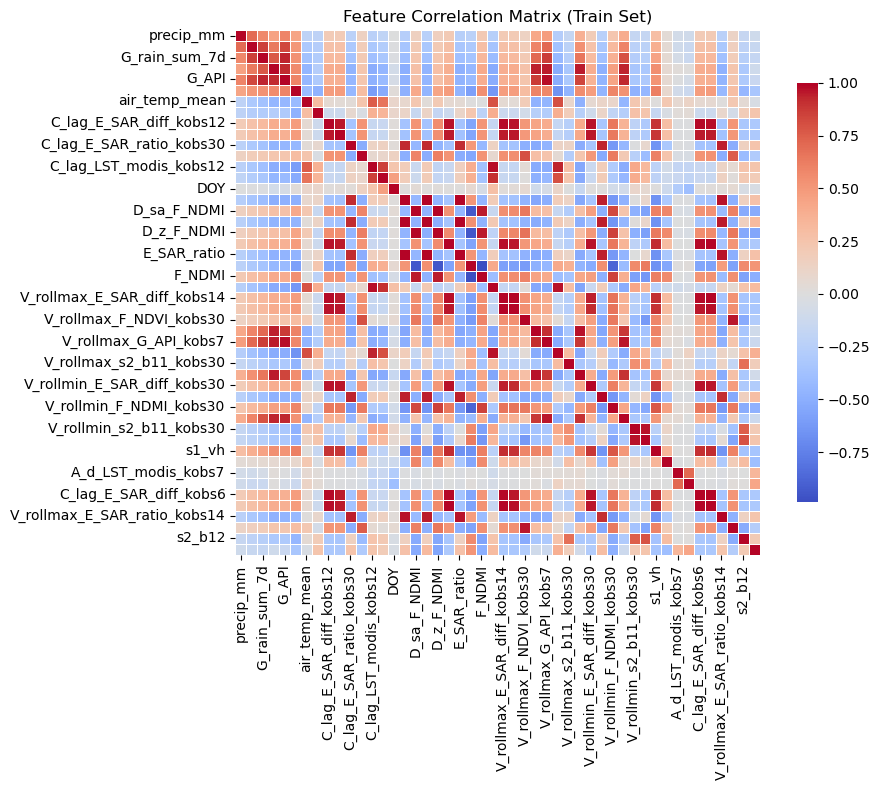

In [12]:
corr = X_train.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
plt.title("Feature Correlation Matrix (Train Set)")
plt.tight_layout()
plt.show()

## 6. Model Definition

Using `optuna` here to find the best hyperparameters for a single XGBoost regressor

In [23]:
def eval_regression(y_true, y_pred, name=""):
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    if name:
        print(f"{name} -> R2: {r2:.5f} | MAE: {mae:.5f} | RMSE: {rmse:.5f}")
    return {"r2": r2, "mae": mae, "rmse": rmse}

In [16]:
def objective(trial):
    params = {
        # early stopping will trim this down
        "n_estimators": 10000,

        # search space
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "max_depth": trial.suggest_int("max_depth", 2, 10),
        "min_child_weight": trial.suggest_float("min_child_weight", 1e-2, 20.0, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "gamma": trial.suggest_float("gamma", 1e-8, 10.0, log=True),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 50.0, log=True),

        # fixed
        "random_state": SEED,
        "objective": "reg:squarederror",
        "tree_method": "hist",
        "n_jobs": -1,

        "eval_metric": "rmse",
    }

    model = XGBRegressor(**params)

    fit_kwargs = dict(
        X=X_train,
        y=y_train,
        eval_set=[(X_val, y_val)],
        verbose=False,
    )

    try:
        fit_kwargs["early_stopping_rounds"] = 200
        fit_kwargs["callbacks"] = [XGBoostPruningCallback(trial, "validation_0-rmse")]
    except Exception:
        pass

    try:
        model.fit(**fit_kwargs)
    except TypeError:
        fit_kwargs.pop("early_stopping_rounds", None)
        fit_kwargs.pop("callbacks", None)
        model.fit(**fit_kwargs)

    yhat_val = model.predict(X_val)
    return r2_score(y_val, yhat_val)

In [17]:
sampler = optuna.samplers.TPESampler(seed=SEED)
pruner = optuna.pruners.MedianPruner(n_warmup_steps=10)

study = optuna.create_study(direction="maximize", sampler=sampler, pruner=pruner)
study.optimize(objective, n_trials=100, show_progress_bar=True)

print("Best validation R2:", study.best_value)
print("Best params:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

[I 2026-02-10 16:42:33,572] A new study created in memory with name: no-name-0c6c74fc-165f-4feb-90c2-386b33917739


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2026-02-10 16:42:54,692] Trial 0 finished with value: 0.8132718248661136 and parameters: {'learning_rate': 0.030710573677773714, 'max_depth': 10, 'min_child_weight': 2.6081583694317696, 'subsample': 0.8394633936788146, 'colsample_bytree': 0.6624074561769746, 'gamma': 2.5348407664333426e-07, 'reg_alpha': 3.3323645788192616e-08, 'reg_lambda': 2.5177723297049526}. Best is trial 0 with value: 0.8132718248661136.
[I 2026-02-10 16:43:08,000] Trial 1 finished with value: 0.7987223540667604 and parameters: {'learning_rate': 0.06054365855469246, 'max_depth': 8, 'min_child_weight': 0.011693648443440112, 'subsample': 0.9879639408647978, 'colsample_bytree': 0.9329770563201687, 'gamma': 8.148018307012941e-07, 'reg_alpha': 4.329370014459266e-07, 'reg_lambda': 6.009451572352867e-07}. Best is trial 0 with value: 0.8132718248661136.
[I 2026-02-10 16:43:37,906] Trial 2 finished with value: 0.8074083046378719 and parameters: {'learning_rate': 0.024878734419814436, 'max_depth': 6, 'min_child_weight': 0

In [18]:
fig1 = plot_optimization_history(study)
fig1.show()

fig2 = plot_param_importances(study)
fig2.show()

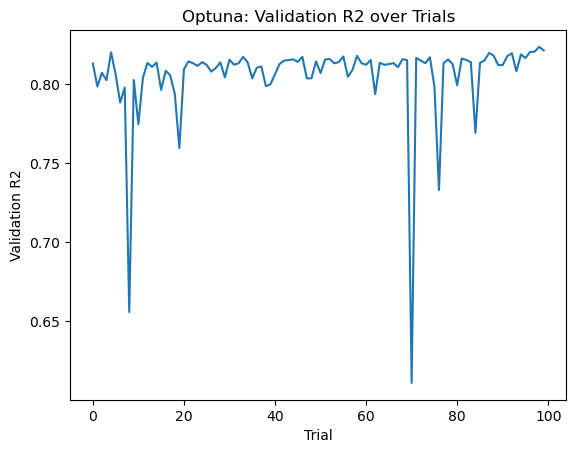

In [21]:
df_trials = study.trials_dataframe()
df_ok = df_trials[df_trials["state"] == "COMPLETE"].copy()

plt.figure()
plt.plot(df_ok["number"], df_ok["value"])
plt.xlabel("Trial")
plt.ylabel("Validation R2")
plt.title("Optuna: Validation R2 over Trials")
plt.show()

In [24]:
best_params = study.best_params.copy()

final_model = XGBRegressor(
    **best_params,
    n_estimators=10000,
    random_state=SEED,
    objective="reg:squarederror",
    tree_method="hist",
    n_jobs=-1,
    eval_metric="rmse",
)

X_trainval = pd.concat([X_train, X_val], axis=0)
y_trainval = np.concatenate([y_train, y_val])

fit_kwargs = dict(
    X=X_trainval,
    y=y_trainval,
    eval_set=[(X_test, y_test)],
    verbose=False,
)

try:
    fit_kwargs["early_stopping_rounds"] = 200
    final_model.fit(**fit_kwargs)
except TypeError:
    fit_kwargs.pop("early_stopping_rounds", None)
    final_model.fit(**fit_kwargs)

yhat_test = final_model.predict(X_test)

print("\nFINAL RESULTS")
eval_regression(y_test, yhat_test, name="Test")

print("\nBest params (final):")
for k, v in best_params.items():
    print(f"  {k}: {v}")


FINAL RESULTS
Test -> R2: 0.77014 | MAE: 0.03470 | RMSE: 0.04606

Best params (final):
  learning_rate: 0.031802897015642956
  max_depth: 8
  min_child_weight: 14.153263657924109
  subsample: 0.9720330017585932
  colsample_bytree: 0.8303197403379534
  gamma: 2.3861026002162537e-08
  reg_alpha: 0.02411624638533363
  reg_lambda: 18.137253935049337


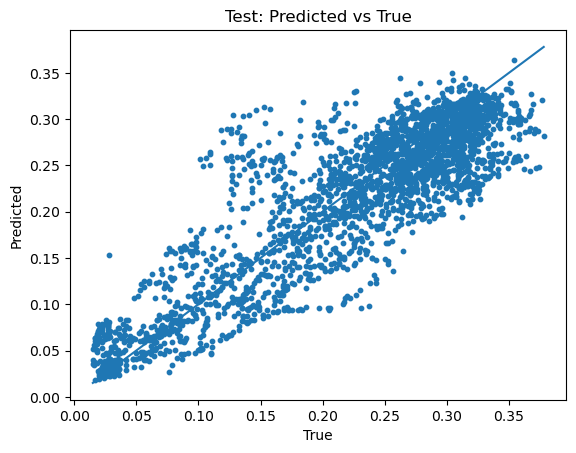

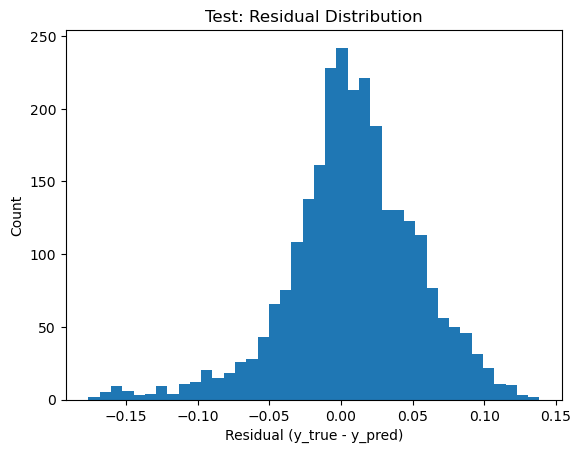

In [25]:
residuals = y_test - yhat_test

# Predicted vs actual
plt.figure()
plt.scatter(y_test, yhat_test, s=10)
mn = min(np.min(y_test), np.min(yhat_test))
mx = max(np.max(y_test), np.max(yhat_test))
plt.plot([mn, mx], [mn, mx])
plt.xlabel("True")
plt.ylabel("Predicted")
plt.title("Test: Predicted vs True")
plt.show()

# Residual histogram
plt.figure()
plt.hist(residuals, bins=40)
plt.xlabel("Residual (y_true - y_pred)")
plt.ylabel("Count")
plt.title("Test: Residual Distribution")
plt.show()

## 7. Post Processing

In [39]:
def metrics(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return {
        "R2": r2_score(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
    }

### 7.1 Initial | Baseline Evaluation

In [40]:
yhat_train = final_model.predict(X_train)
yhat_val   = final_model.predict(X_val)
yhat_test  = final_model.predict(X_test)

results = {}

results["baseline"] = {
    "val":  metrics(y_val,  yhat_val),
    "test": metrics(y_test, yhat_test),
}

print("Baseline ready")
print("  Val :", results["baseline"]["val"])
print("  Test:", results["baseline"]["test"])

Baseline ready
  Val : {'R2': 0.9996841494924797, 'MAE': 0.0012702287910285976, 'RMSE': 0.0017899807450619846}
  Test: {'R2': 0.7701396358325784, 'MAE': 0.034699320849892835, 'RMSE': 0.04605700513492031}


### 7.2 Linear Calibration

In [41]:
from sklearn.linear_model import LinearRegression

cal = LinearRegression()
cal.fit(yhat_val.reshape(-1, 1), np.asarray(y_val))

yhat_val_cal  = cal.predict(yhat_val.reshape(-1, 1))
yhat_test_cal = cal.predict(yhat_test.reshape(-1, 1))

results["global_calibration"] = {
    "val":  metrics(y_val,  yhat_val_cal),
    "test": metrics(y_test, yhat_test_cal),
}

print("Global calibration ready")
print("  Val :", results["global_calibration"]["val"])
print("  Test:", results["global_calibration"]["test"])

Global calibration ready
  Val : {'R2': 0.9996845426300147, 'MAE': 0.0012701637014904913, 'RMSE': 0.0017888664081950982}
  Test: {'R2': 0.770120982278629, 'MAE': 0.03469621698730375, 'RMSE': 0.046058873898602026}


### 7.3 Residual Model

In [42]:
from xgboost import XGBRegressor

res_train = np.asarray(y_train) - yhat_train
res_val   = np.asarray(y_val)   - yhat_val

res_model = XGBRegressor(
    n_estimators=800,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_alpha=0.0,
    reg_lambda=1.0,
    random_state=SEED,
    objective="reg:squarederror",
    tree_method="hist",
    n_jobs=-1,
    eval_metric="rmse",
)

fit_kwargs = dict(
    X=X_train,
    y=res_train,
    eval_set=[(X_val, res_val)],
    verbose=False,
)

try:
    fit_kwargs["early_stopping_rounds"] = 100
    res_model.fit(**fit_kwargs)
except TypeError:
    fit_kwargs.pop("early_stopping_rounds", None)
    res_model.fit(**fit_kwargs)

res_hat_val  = res_model.predict(X_val)
res_hat_test = res_model.predict(X_test)

yhat_val_res  = yhat_val  + res_hat_val
yhat_test_res = yhat_test + res_hat_test

results["residual_model"] = {
    "val":  metrics(y_val,  yhat_val_res),
    "test": metrics(y_test, yhat_test_res),
}

print("Residual model ready")
print("  Val :", results["residual_model"]["val"])
print("  Test:", results["residual_model"]["test"])

Residual model ready
  Val : {'R2': 0.9996544236922501, 'MAE': 0.001329104132610831, 'RMSE': 0.00187231772970986}
  Test: {'R2': 0.7697830034687883, 'MAE': 0.034690071352495876, 'RMSE': 0.04609272041042378}


### 7.4 Bootstrapping

In [ ]:
N_BOOT = 500
RANDOM_STATE = 42

rng = np.random.default_rng(RANDOM_STATE)
n_test = len(y_test)

print(f"Bootstrapping with N={N_BOOT}, test size={n_test}")

Bootstrapping with N=500, test size=2659


In [45]:
boot_results = {
    "r2": [],
    "mae": [],
    "rmse": [],
}

y_test_np = np.asarray(y_test)
yhat_test_np = np.asarray(yhat_test)

for i in range(N_BOOT):
    idx = rng.integers(0, n_test, size=n_test)

    y_true_b = y_test_np[idx]
    y_pred_b = yhat_test_np[idx]

    boot_results["r2"].append(r2_score(y_true_b, y_pred_b))
    boot_results["mae"].append(mean_absolute_error(y_true_b, y_pred_b))
    boot_results["rmse"].append(np.sqrt(mean_squared_error(y_true_b, y_pred_b)))

print("Bootstrapping complete")

Bootstrapping complete


In [46]:
def summarize_bootstrap(x, name):
    x = np.array(x)
    mean = x.mean()
    lo, hi = np.percentile(x, [2.5, 97.5])
    std = x.std()

    print(
        f"{name}: "
        f"mean={mean:.4f}, std={std:.4f}, "
        f"95% CI=[{lo:.4f}, {hi:.4f}]"
    )

summarize_bootstrap(boot_results["r2"], "R2")
summarize_bootstrap(boot_results["mae"], "MAE")
summarize_bootstrap(boot_results["rmse"], "RMSE")

R2: mean=0.7697, std=0.0093, 95% CI=[0.7510, 0.7877]
MAE: mean=0.0347, std=0.0006, 95% CI=[0.0335, 0.0358]
RMSE: mean=0.0461, std=0.0008, 95% CI=[0.0446, 0.0475]


---

_Jakob Balkovec_